In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

def mk_saltless_PBS(conc, volume, pH):

    # 原始離散 pH 與磷酸鹽比例 (%)
    pH_range = [round(5.8 + 0.2 * i, 1) for i in range(int((8.0 - 5.8) / 0.2) + 1)]
    K2HPO4 = [8.5, 13.2, 19.2, 27.8, 38.1, 49.7, 61.5, 71.7, 80.2, 86.6, 90.8, 94.0]
    KH2PO4 = [91.5, 86.8, 80.8, 72.2, 61.9, 50.3, 38.5, 28.3, 19.8, 13.4, 9.2, 6.0]

    # 分子量
    MW_K2HPO4 = 174.18  # g/mol
    MW_KH2PO4 = 136.09  # g/mol

    # Cubic Spline 平滑函數（對每對相鄰點用 3 次多項式逼近）
    spline_K2HPO4 = CubicSpline(pH_range, K2HPO4)
    spline_KH2PO4 = CubicSpline(pH_range, KH2PO4)

    # 細化的 pH 序列，用來畫平滑曲線
    pH_interp = np.linspace(5.8, 8.0, 500)
    K2HPO4_interp = spline_K2HPO4(pH_interp)
    KH2PO4_interp = spline_KH2PO4(pH_interp)

    # 標準化濃度（轉換為實際濃度）
    if conc:
        total_phosphate = K2HPO4_interp + KH2PO4_interp
        K2HPO4_interp = np.round(K2HPO4_interp / total_phosphate * conc, 2)
        KH2PO4_interp = np.round(KH2PO4_interp / total_phosphate * conc, 2)

    # 👉 查詢輸入的 pH 對應濃度
    if not 5.8 <= pH <= 8.0:
        print(f'⚠️ pH {pH} 超出範圍（5.8 - 8.0）')
        return

    K2H = spline_K2HPO4(pH)
    KH2 = spline_KH2PO4(pH)
    total = K2H + KH2
    K2H_conc = round(K2H / total * conc, 2)  # mM
    KH2_conc = round(KH2 / total * conc, 2)  # mM

    # 換算克數（conc 為 mmol/L，因此乘分子量後乘體積）
    K2H_mmol = K2H_conc * volume/1000  # mmol
    KH2_mmol = KH2_conc * volume/1000  # mmol
    K2H_mass = round(K2H_mmol * MW_K2HPO4 / 1000, 4)  # g
    KH2_mass = round(KH2_mmol * MW_KH2PO4 / 1000, 4)  # g

    # 畫圖
    plt.figure(figsize=(9, 5))
    plt.plot(pH_interp, K2HPO4_interp, label='K₂HPO₄', color='blue')
    plt.plot(pH_interp, KH2PO4_interp, label='KH₂PO₄', color='red')
    plt.axvline(pH, color='gray', linestyle='--', alpha=0.3, linewidth=5, label=f'pH = {pH}')
    plt.xlabel('pH')
    plt.ylabel(f'Concentration (mM)' if conc else 'Relative amount (%)')
    plt.ylim(0, conc)
    plt.title('Smoothed Saltless PBS Composition vs pH')
    plt.xticks(np.arange(5.8, 8.01, 0.2))  # 每 0.2 一格的 x 軸
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 顯示建議濃度
    print(f'📘 PBS 配方建議（pH = {pH}, 濃度 = {conc} mM, 體積 = {volume} mL）:')
    print(f'  ➤ K₂HPO₄：{K2H_conc} mM → {K2H_mmol} mmol → {K2H_mass} g')
    print(f'  ➤ KH₂PO₄：{KH2_conc} mM → {KH2_mmol} mmol → {KH2_mass} g')

    return {
        'K2HPO4_mM': K2H_conc,
        'KH2PO4_mM': KH2_conc,
        'K2HPO4_g': K2H_mass,
        'KH2PO4_g': KH2_mass
    }

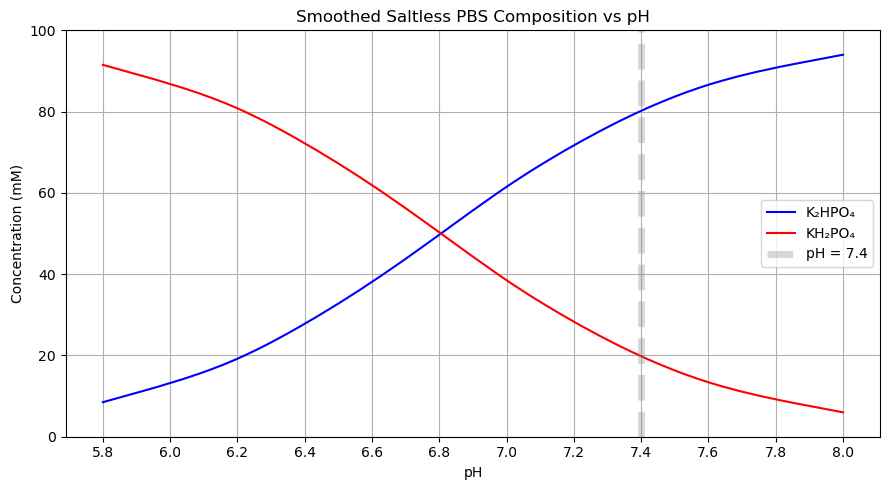

📘 PBS 配方建議（pH = 7.4, 濃度 = 100.0 mM, 體積 = 200.0 mL）:
  ➤ K₂HPO₄：80.2 mM → 16.04 mmol → 2.7938 g
  ➤ KH₂PO₄：19.8 mM → 3.96 mmol → 0.5389 g


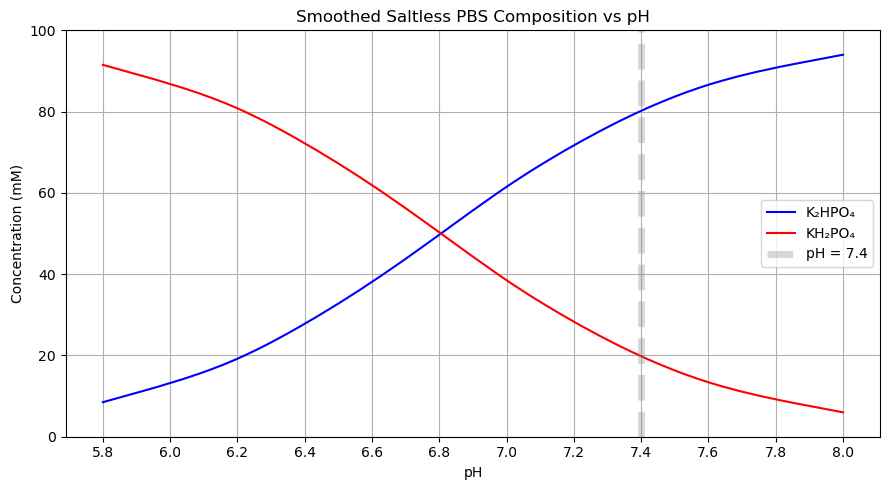

📘 PBS 配方建議（pH = 7.4, 濃度 = 100.0 mM, 體積 = 200.0 mL）:
  ➤ K₂HPO₄：80.2 mM → 16.04 mmol → 2.7938 g
  ➤ KH₂PO₄：19.8 mM → 3.96 mmol → 0.5389 g


In [ ]:
import tkinter as tk
from tkinter import messagebox
# 你原本寫好的函數貼在這裡 👇
# from your_module import mk_saltless_PBS  # 或者直接把 mk_saltless_PBS 貼進這個檔案中

# 建立 GUI
def main_gui():
    def on_submit():
        try:
            conc = float(entry_conc.get())
            volume = float(entry_vol.get())
            pH = float(entry_pH.get())
        except ValueError:
            messagebox.showerror("錯誤", "請輸入有效的數字！")
            return

        if not (5.8 <= pH <= 8.0):
            messagebox.showerror("錯誤", "pH 必須在 5.8 到 8.0 範圍內")
            return

        result = mk_saltless_PBS(conc, volume, pH)
        if result:
            message = (
                f"📘 PBS 配方建議：\n"
                f"濃度：{conc} mM\n體積：{volume} mL\npH：{pH}\n\n"
                f"K₂HPO₄：{result['K2HPO4_mM']} mM → {result['K2HPO4_g']} g\n"
                f"KH₂PO₄：{result['KH2PO4_mM']} mM → {result['KH2PO4_g']} g"
            )
            messagebox.showinfo("計算結果", message)

    # 建立視窗
    root = tk.Tk()
    root.title("PBS 緩衝液配方小工具")
    root.geometry("300x200")

    # 元件
    tk.Label(root, text="濃度 (mM):").grid(row=0, column=0, sticky='e', padx=5, pady=5)
    tk.Label(root, text="體積 (mL):").grid(row=1, column=0, sticky='e', padx=5, pady=5)
    tk.Label(root, text="pH 值:").grid(row=2, column=0, sticky='e', padx=5, pady=5)

    entry_conc = tk.Entry(root)
    entry_conc.grid(row=0, column=1, padx=5)
    entry_conc.insert(0, "100")

    entry_vol = tk.Entry(root)
    entry_vol.grid(row=1, column=1, padx=5)
    entry_vol.insert(0, "200")

    entry_pH = tk.Entry(root)
    entry_pH.grid(row=2, column=1, padx=5)
    entry_pH.insert(0, "7.4")

    tk.Button(root, text="計算 PBS", command=on_submit).grid(row=3, column=0, columnspan=2, pady=15)

    root.mainloop()

# 執行 GUI
if __name__ == '__main__':
    main_gui()

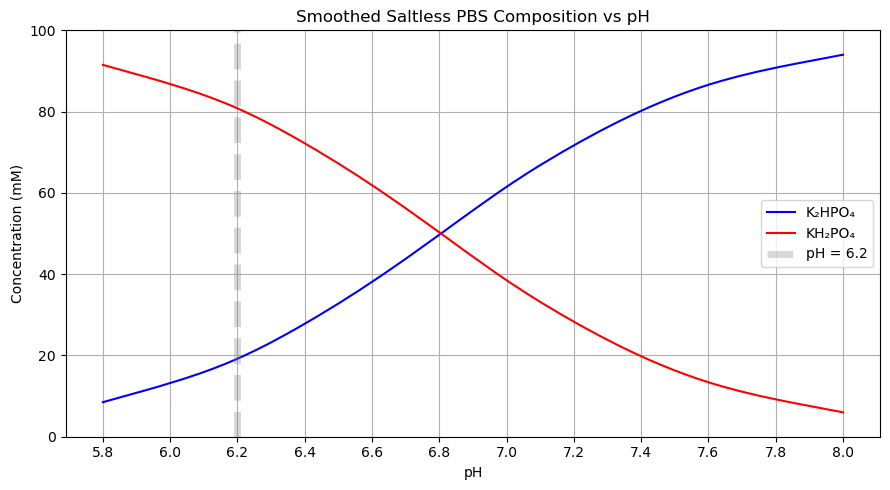

📘 PBS 配方建議（pH = 6.2, 濃度 = 100 mM, 體積 = 200 mL）:
  ➤ K₂HPO₄：19.2 mM → 3.84 mmol → 0.6689 g
  ➤ KH₂PO₄：80.8 mM → 16.16 mmol → 2.1992 g


{'K2HPO4_mM': 19.2, 'KH2PO4_mM': 80.8, 'K2HPO4_g': 0.6689, 'KH2PO4_g': 2.1992}

In [ ]:
# 無鈉PBS的（濃度(mmol)、體積(mL)、pH值）
mk_saltless_PBS(100,  200, 7)